In [1]:
# # This Python 3 environment comes with many helpful analytics libraries installed
# # It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# # For example, here's several helpful packages to load

# import numpy as np # linear algebra
# import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# # Input data files are available in the read-only "../input/" directory
# # For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

# import os
# for dirname, _, filenames in os.walk('/kaggle/input'):
#     for filename in filenames:
#         print(os.path.join(dirname, filename))

# # You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# # You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# # Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# # Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

# import kagglehub
# # kagglehub.dataset_download('<owner>/<dataset-slug>')

In [2]:
from sklearn.preprocessing import StandardScaler
import torch
from torchvision import datasets
from torchvision.transforms import v2
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_squared_error
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report

# training image preprocessing

In [3]:
# Defining the preprocessing pipeline for every image 
#comspose tell that do this for each individual image
transform = v2.Compose([

    # Convert the image into a PyTorch image tensor
    # RGB image → [3, H, W]
    v2.ToImage(),

    # Resize every image to 128 × 128 pixels
    # Equivalent to image_size=(128, 128) in Keras
    v2.Resize((128, 128)),

    # Convert pixel values to float32  
    # and scale them from 0–255 to 0–1
    v2.ToDtype(torch.float32, scale=True)
])


# Path to the training folder
train_path = "/kaggle/input/datasets/vipoooool/new-plant-diseases-dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train"


# Path to the validation folder
valid_path = "/kaggle/input/datasets/vipoooool/new-plant-diseases-dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/valid"


# Load the training dataset
# ImageFolder:
# 1. Finds all class folders
# 2. Assigns an integer label to each class
# 3. Stores the image paths and labels
train_dataset = datasets.ImageFolder(
    root=train_path,
    transform=transform
)


# Load the validation dataset
valid_dataset = datasets.ImageFolder(
    root=valid_path,
    transform=transform
)


# Find the number of classes
num_classes = len(train_dataset.classes)

print("Number of classes:", num_classes)


# Find the total number of training images
print("Training images:", len(train_dataset))


# Find the total number of validation images
print("Validation images:", len(valid_dataset))


# Create the training DataLoader
# batch_size=32 → 32 images are processed together
# shuffle=True → randomly shuffle training images
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)


# Create the validation DataLoader
# We don't need to shuffle validation data
valid_loader = DataLoader(
    valid_dataset,
    batch_size=32,
    shuffle=False
)


# Get one batch from the training DataLoader
images, labels = next(iter(train_loader))


# Check the shape of the batch
print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)


# Display some of the labels
print("First 10 labels:", labels[:10])

Number of classes: 38
Training images: 70295
Validation images: 17572
Image batch shape: torch.Size([32, 3, 128, 128])
Label batch shape: torch.Size([32])
First 10 labels: tensor([23, 18,  9, 25,  5, 30, 23,  9,  0, 20])


In [4]:
print(train_dataset.class_to_idx)
''' this .class_to_idx .classes are function given by datasets ImageFolder,
it is a Python class provided by TorchVision. That class is designed with certain attributes and 
methods.'''

{'Apple___Apple_scab': 0, 'Apple___Black_rot': 1, 'Apple___Cedar_apple_rust': 2, 'Apple___healthy': 3, 'Blueberry___healthy': 4, 'Cherry_(including_sour)___Powdery_mildew': 5, 'Cherry_(including_sour)___healthy': 6, 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot': 7, 'Corn_(maize)___Common_rust_': 8, 'Corn_(maize)___Northern_Leaf_Blight': 9, 'Corn_(maize)___healthy': 10, 'Grape___Black_rot': 11, 'Grape___Esca_(Black_Measles)': 12, 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)': 13, 'Grape___healthy': 14, 'Orange___Haunglongbing_(Citrus_greening)': 15, 'Peach___Bacterial_spot': 16, 'Peach___healthy': 17, 'Pepper,_bell___Bacterial_spot': 18, 'Pepper,_bell___healthy': 19, 'Potato___Early_blight': 20, 'Potato___Late_blight': 21, 'Potato___healthy': 22, 'Raspberry___healthy': 23, 'Soybean___healthy': 24, 'Squash___Powdery_mildew': 25, 'Strawberry___Leaf_scorch': 26, 'Strawberry___healthy': 27, 'Tomato___Bacterial_spot': 28, 'Tomato___Early_blight': 29, 'Tomato___Late_blight': 30, 'Tomato

' this .class_to_idx .classes are function given by datasets ImageFolder,\nit is a Python class provided by TorchVision. That class is designed with certain attributes and \nmethods.'

In [5]:
print(train_dataset.classes)

['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy', 'Cherry_(including_sour)___Powdery_mildew', 'Cherry_(including_sour)___healthy', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Common_rust_', 'Corn_(maize)___Northern_Leaf_Blight', 'Corn_(maize)___healthy', 'Grape___Black_rot', 'Grape___Esca_(Black_Measles)', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Grape___healthy', 'Orange___Haunglongbing_(Citrus_greening)', 'Peach___Bacterial_spot', 'Peach___healthy', 'Pepper,_bell___Bacterial_spot', 'Pepper,_bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Raspberry___healthy', 'Soybean___healthy', 'Squash___Powdery_mildew', 'Strawberry___Leaf_scorch', 'Strawberry___healthy', 'Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___Septoria_leaf_spot', 'Tomato___Spider_mites Two-spotted_spider_mite', 'Tomato___Target_Sp

In [6]:
for x,y in train_loader:
    print(x,x.shape)
    print(y,y.shape)
    break;

tensor([[[[0.3490, 0.3451, 0.3608,  ..., 0.3922, 0.3882, 0.3843],
          [0.3686, 0.3529, 0.3608,  ..., 0.4000, 0.3882, 0.3804],
          [0.3490, 0.3608, 0.3529,  ..., 0.3961, 0.3843, 0.3804],
          ...,
          [0.4745, 0.4667, 0.4510,  ..., 0.3647, 0.3529, 0.3608],
          [0.4784, 0.4627, 0.4353,  ..., 0.3765, 0.4157, 0.4431],
          [0.4510, 0.4275, 0.4118,  ..., 0.3686, 0.4078, 0.4078]],

         [[0.3373, 0.3333, 0.3490,  ..., 0.3843, 0.3804, 0.3765],
          [0.3569, 0.3412, 0.3490,  ..., 0.3922, 0.3804, 0.3725],
          [0.3373, 0.3490, 0.3412,  ..., 0.3882, 0.3765, 0.3725],
          ...,
          [0.5765, 0.5686, 0.5490,  ..., 0.4784, 0.4667, 0.4784],
          [0.5804, 0.5647, 0.5373,  ..., 0.4941, 0.5333, 0.5608],
          [0.5529, 0.5294, 0.5137,  ..., 0.4863, 0.5255, 0.5255]],

         [[0.4039, 0.4000, 0.4157,  ..., 0.4706, 0.4667, 0.4627],
          [0.4235, 0.4078, 0.4157,  ..., 0.4784, 0.4667, 0.4588],
          [0.4039, 0.4157, 0.4078,  ..., 0

# Building The model

In [7]:
class CNN(nn.Module):
    def __init__(self):
        super(CNN,self).__init__()
        self.model=nn.Sequential(
            #image is of from (channel,height,width)=(3,128,128)
            # so input has three channels
            #`1st Block-----------------------------------------------------------
            nn.Conv2d(3,32,kernel_size=3,padding=1),
        #so here basically We applying 32 different learnable filters to the input image,
            #producing 32 feature maps.
            nn.ReLU(),
            # at this point we have 32*128*128
        
            nn.Conv2d(32,32,kernel_size=3),
            #padding is not used here so the height and width will decrease by 2
            #1st layer can learn relatively simpler pattern/feature by doing convolution on 
            #those features model can learn relatively complex pattern
            nn.ReLU(),

           #at this point we have 32*128*128
            nn.MaxPool2d(kernel_size=2,stride=2),

            #this is kind of down sampling and at this stage we will have 32*63*63

            #The first block works with relatively detailed spatial information 
            #and begins extracting basic visual features.
                                        #---------------------------#
            #2nd block------------------
            nn.Conv2d(32,64,kernel_size=3,padding=1),
            nn.ReLU(),
            #now we have 64 feature maps so 64*63*63

            nn.Conv2d(64, 64, kernel_size=3),
            #padding is not used here so the height and width will decrease by 2
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            #now we have 64*30*30
                                #---------------------------------#
            #3rd block
            nn.Conv2d(64,128,kernel_size=3,padding=1),
            nn.ReLU(),
            #now we have 128 feature maps so 128*30*30

            nn.Conv2d(128, 128, kernel_size=3),
            #padding is not used here so the height and width will decrease by 2
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
                                            #---------------------------------#

            nn.Conv2d(128,256,kernel_size=3,padding=1),
            nn.ReLU(),
            nn.Conv2d(256, 256, kernel_size=3),
            #padding is not used here so the height and width will decrease by 2
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            #now we have 256*6*6


            #adding one more layer to solve underfitting
            nn.Conv2d(256,512,kernel_size=3,padding=1),
            nn.ReLU(),
            nn.Conv2d(512, 512, kernel_size=3),
            #padding is not used here so the height and width will decrease by 2
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            
            nn.Dropout(0.25),#to avoid overfitting droping out 25% feature matrix
            
            #fully connected layer
            nn.Flatten(),#after flatening we will have 512*2*2 input so we will map them to 1024(increased to 1500) neuron
            nn.Linear(512 * 2 * 2, 1500),#increases the no of neuron
            nn.ReLU(),
            #o/p layer
            nn.Dropout(p=0.4),#to avoid overfitting dropping 40% neuron
            nn.Linear(1500,38),
            
            #we dont use max_soft as we will use cross-entropy for validation which uses softmax
            #by it self
        )

    def forward(self,x):
        return self.model(x)

In [8]:
from torchinfo import summary
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = CNN().to(device)
summary(model, input_size=(1, 3, 128, 128))

Layer (type:depth-idx)                   Output Shape              Param #
CNN                                      [1, 38]                   --
├─Sequential: 1-1                        [1, 38]                   --
│    └─Conv2d: 2-1                       [1, 32, 128, 128]         896
│    └─ReLU: 2-2                         [1, 32, 128, 128]         --
│    └─Conv2d: 2-3                       [1, 32, 126, 126]         9,248
│    └─ReLU: 2-4                         [1, 32, 126, 126]         --
│    └─MaxPool2d: 2-5                    [1, 32, 63, 63]           --
│    └─Conv2d: 2-6                       [1, 64, 63, 63]           18,496
│    └─ReLU: 2-7                         [1, 64, 63, 63]           --
│    └─Conv2d: 2-8                       [1, 64, 61, 61]           36,928
│    └─ReLU: 2-9                         [1, 64, 61, 61]           --
│    └─MaxPool2d: 2-10                   [1, 64, 30, 30]           --
│    └─Conv2d: 2-11                      [1, 128, 30, 30]          73,856

# **training model**

In [9]:
# criterion = nn.CrossEntropyLoss()

# optimizer = torch.optim.Adam(
#     model.parameters()
#     learning_rate=0.0001
# )

In [10]:
# validation_loss=[]
# training_loss=[]
# min_val_loss=float('inf')

# for epoch in range(10):
#     model.train()
#     running_loss = 0.0
 
#     for xb,yb in train_loader:
#         optimizer.zero_grad()
#         xb = xb.to(device)
#         yb = yb.to(device)

#         outputs=model(xb)
#         loss=criterion(outputs,yb)

#         loss.backward()#back-propagation
#         optimizer.step()

#         running_loss+=loss.item()#gives val in float ,as loss is a tensor

#     epoch_loss=running_loss/len(train_loader)
#     training_loss.append(epoch_loss)

#     model.eval()
#     running_val_loss=0.0

#     with torch.no_grad():
#         for xb,yb in valid_loader:
#             xb = xb.to(device)
#             yb = yb.to(device)
            
#             outputs=model(xb)
#             loss=criterion(outputs,yb)
#             running_val_loss += loss.item()

#         epoch_val_loss=running_val_loss/len(valid_loader)
#         validation_loss.append(epoch_val_loss)

#         if epoch_val_loss < min_val_loss:
#             min_val_loss = epoch_val_loss
#             torch.save(model.state_dict(), 'best_model.pt')
#             print(f"Best model saved with Validation Loss: {min_val_loss:.4f}")

### To avoid Overshooting

1. Choose small learning rate default 0.001, we are taking 0.0001
2. There may be chance of Underfitting, so increase number of neuron
3. Add more Convolution layer to extract more feature from images there may be possibility that model unable to capture relevant feature or model is confusing due to lack of feature so

#GPU VERSION FOR FAST TRAINING

In [11]:
device = torch.device("cuda")

model = CNN()
model = nn.DataParallel(model, device_ids=[0, 1])
model = model.to(device)

In [12]:
train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True,
    num_workers=4,
    pin_memory=True,
    persistent_workers=True
)

valid_loader = DataLoader(
    valid_dataset,
    batch_size=64,
    shuffle=False,
    num_workers=4,
    pin_memory=True,
    persistent_workers=True
)

In [13]:
device = torch.device("cuda")

model = CNN()
model = nn.DataParallel(model, device_ids=[0, 1])
model = model.to(device)

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(model.parameters(), lr=0.0001)

scaler = torch.amp.GradScaler("cuda")

In [14]:
validation_loss=[]
training_loss=[]
min_val_loss=float('inf')

scaler = torch.amp.GradScaler("cuda")

for epoch in range(20):
    model.train()
    running_loss = 0.0
 
    for xb,yb in train_loader:
        xb = xb.to(device, non_blocking=True)
        yb = yb.to(device, non_blocking=True)

        optimizer.zero_grad()

        with torch.autocast(device_type="cuda", dtype=torch.float16):
            outputs=model(xb)
            loss=criterion(outputs,yb)

        scaler.scale(loss).backward()#back-propagation
        scaler.step(optimizer)
        scaler.update()

        running_loss+=loss.item()#gives val in float ,as loss is a tensor

    epoch_loss=running_loss/len(train_loader)
    training_loss.append(epoch_loss)

    model.eval()
    running_val_loss=0.0

    with torch.no_grad():
        for xb,yb in valid_loader:
            xb = xb.to(device, non_blocking=True)
            yb = yb.to(device, non_blocking=True)
            
            with torch.autocast(device_type="cuda", dtype=torch.float16):
                outputs=model(xb)
                loss=criterion(outputs,yb)

            running_val_loss += loss.item()

        epoch_val_loss=running_val_loss/len(valid_loader)
        validation_loss.append(epoch_val_loss)

        if epoch_val_loss < min_val_loss:
            min_val_loss = epoch_val_loss
            torch.save(model.module.state_dict(), 'best_model.pt')
            print(f"Best model saved with Validation Loss: {min_val_loss:.4f}")

Best model saved with Validation Loss: 1.5537
Best model saved with Validation Loss: 1.0568
Best model saved with Validation Loss: 0.6737
Best model saved with Validation Loss: 0.5013
Best model saved with Validation Loss: 0.4212
Best model saved with Validation Loss: 0.3678
Best model saved with Validation Loss: 0.3105
Best model saved with Validation Loss: 0.2789
Best model saved with Validation Loss: 0.2285
Best model saved with Validation Loss: 0.2164
Best model saved with Validation Loss: 0.2134
Best model saved with Validation Loss: 0.2071
Best model saved with Validation Loss: 0.1779
Best model saved with Validation Loss: 0.1722
Best model saved with Validation Loss: 0.1431


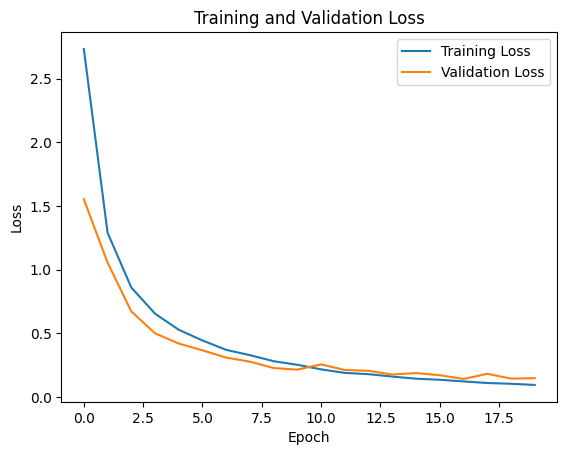

In [15]:
import matplotlib.pyplot as plt

loss_df = pd.DataFrame({
	"Training Loss": training_loss,
	"Validation Loss": validation_loss
})

loss_df.plot()
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.show()

In [16]:
device = torch.device("cpu")

model = CNN().to(device)

model.load_state_dict(
    torch.load("best_model.pt", map_location=device)
)

model.eval()

CNN(
  (model): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU()
    (7): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1))
    (8): ReLU()
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU()
    (12): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1))
    (13): ReLU()
    (14): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (15): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (16): ReLU()
    (17): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1))
    (18): ReLU()
    (19): MaxPool2d(kernel_size=2, stride

In [17]:
model.eval()

y_true = []
y_pred = []

with torch.no_grad():
    for xb, yb in valid_loader:
        xb = xb.to(device)
        yb = yb.to(device)

        outputs = model(xb)
        predictions = torch.argmax(outputs, dim=1)

        y_true.extend(yb.numpy())
        y_pred.extend(predictions.numpy())

In [18]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_true, y_pred)

precision = precision_score(
    y_true, y_pred,
    average="weighted",
    zero_division=0
)

recall = recall_score(
    y_true, y_pred,
    average="weighted",
    zero_division=0
)

f1 = f1_score(
    y_true, y_pred,
    average="weighted",
    zero_division=0
)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

Accuracy : 0.9537
Precision: 0.9541
Recall   : 0.9537
F1 Score : 0.9536


In [19]:
print(classification_report(
    y_true,
    y_pred,
    target_names=valid_dataset.classes,
    zero_division=0
))

                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       0.94      0.91      0.93       504
                                 Apple___Black_rot       0.97      0.96      0.97       497
                          Apple___Cedar_apple_rust       0.98      0.95      0.96       440
                                   Apple___healthy       0.95      0.93      0.94       502
                               Blueberry___healthy       0.92      0.98      0.95       454
          Cherry_(including_sour)___Powdery_mildew       0.98      0.98      0.98       421
                 Cherry_(including_sour)___healthy       0.99      0.98      0.99       456
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.85      0.94      0.89       410
                       Corn_(maize)___Common_rust_       1.00      0.98      0.99       477
               Corn_(maize)___Northern_Leaf_Blight       0.95      0.88      0.

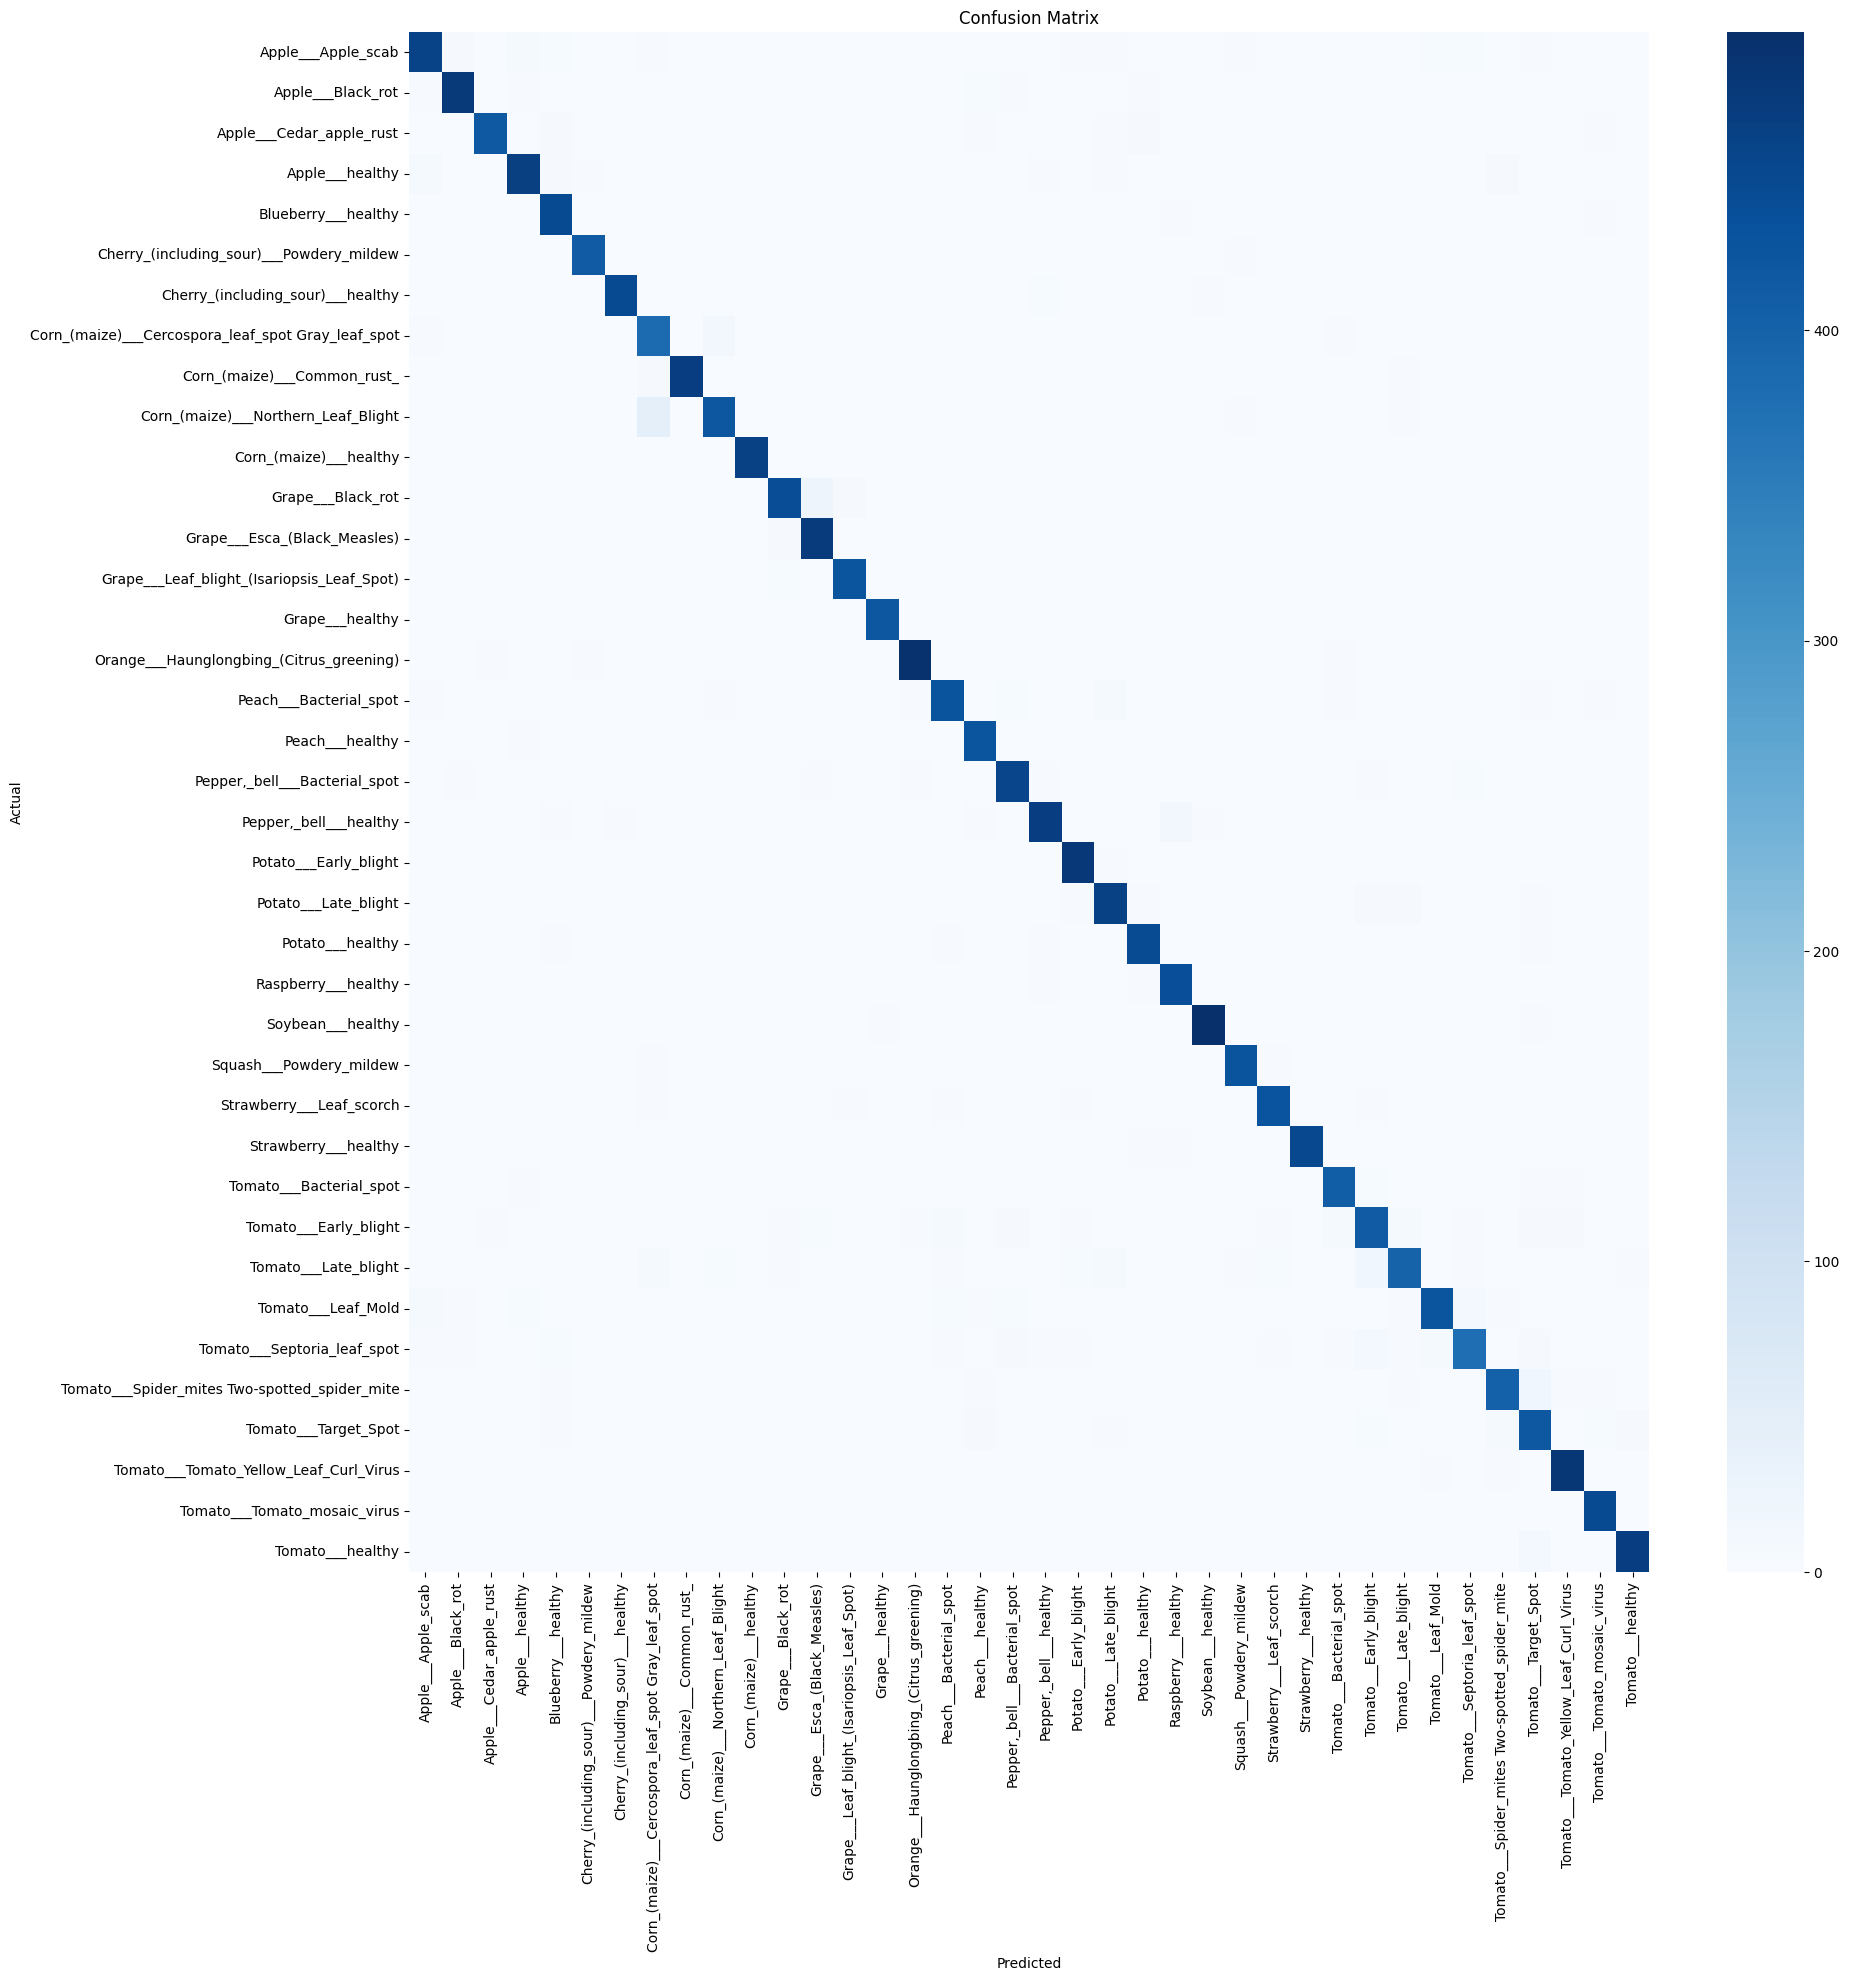

In [20]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(20, 20))

sns.heatmap(
    cm,
    annot=False,
    cmap="Blues",
    xticklabels=valid_dataset.classes,
    yticklabels=valid_dataset.classes
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.show()

In [21]:
import numpy as np

for i in range(len(cm)):
    for j in range(len(cm)):
        if i != j and cm[i, j] > 0:
            print(
                valid_dataset.classes[i],
                "->",
                valid_dataset.classes[j],
                ":",
                cm[i, j]
            )

Apple___Apple_scab -> Apple___Black_rot : 6
Apple___Apple_scab -> Apple___healthy : 8
Apple___Apple_scab -> Blueberry___healthy : 5
Apple___Apple_scab -> Cherry_(including_sour)___Powdery_mildew : 1
Apple___Apple_scab -> Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot : 3
Apple___Apple_scab -> Grape___healthy : 1
Apple___Apple_scab -> Potato___Early_blight : 2
Apple___Apple_scab -> Potato___Late_blight : 2
Apple___Apple_scab -> Squash___Powdery_mildew : 2
Apple___Apple_scab -> Tomato___Leaf_Mold : 4
Apple___Apple_scab -> Tomato___Septoria_leaf_spot : 5
Apple___Apple_scab -> Tomato___Spider_mites Two-spotted_spider_mite : 1
Apple___Apple_scab -> Tomato___Target_Spot : 2
Apple___Apple_scab -> Tomato___healthy : 1
Apple___Black_rot -> Apple___Apple_scab : 2
Apple___Black_rot -> Apple___healthy : 2
Apple___Black_rot -> Blueberry___healthy : 1
Apple___Black_rot -> Cherry_(including_sour)___healthy : 1
Apple___Black_rot -> Peach___healthy : 5
Apple___Black_rot -> Pepper,_bell___Bacterial_

# visualizing test set

In [22]:
import cv2 #opencv library

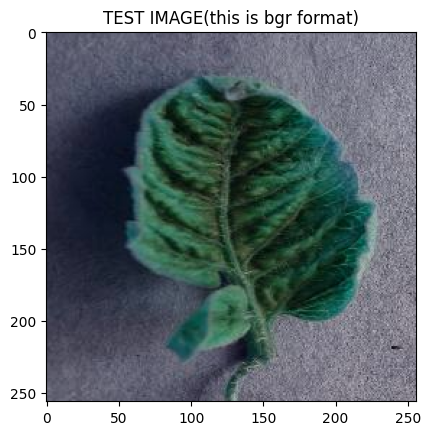

In [23]:
img_path="/kaggle/input/datasets/vipoooool/new-plant-diseases-dataset/test/test/TomatoYellowCurlVirus2.JPG"
#reading img
img=cv2.imread(img_path)
#display image
plt.imshow(img)
plt.title("TEST IMAGE(this is bgr format)")
plt.show()

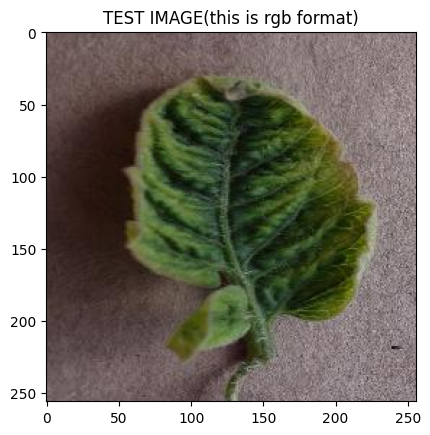

In [24]:
img=cv2.cvtColor(img,cv2.COLOR_BGR2RGB)
plt.imshow(img)
plt.title("TEST IMAGE(this is rgb format)")
plt.show()

# Testing Model

In [25]:
transform = v2.Compose([
    v2.ToImage(),
    v2.Resize((128,128)),
    v2.ToDtype(torch.float32, scale=True)
])

input_tensor = transform(img)
input_tensor = input_tensor.unsqueeze(0).to(device)

print(input_tensor.shape)
print(input_tensor.dtype)

torch.Size([1, 3, 128, 128])
torch.float32


In [26]:
model.eval()

with torch.no_grad():
    prediction = model(input_tensor)

In [27]:
prediction

tensor([[-23.8943, -17.6044,  -7.1021, -11.6647, -27.2839,  -8.8538, -35.6045,
         -15.9103, -30.3811, -20.1595, -27.1533,  -5.0730,  -8.0132, -14.2735,
         -20.0588, -10.8715, -13.4676, -27.7189,   0.7626, -22.5118, -30.2764,
         -10.5239, -14.0695,  -7.6945, -18.4559, -16.4913, -14.2646, -32.1994,
           0.2114,   3.9026,  -2.5326,  -7.9833, -10.7883,   1.2782,  -8.6572,
          16.9269, -22.0296, -30.0125]])

In [28]:
result_index=np.argmax(prediction)

In [29]:
result_index

tensor(35)

In [30]:
class_name=['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy', 'Cherry_(including_sour)___Powdery_mildew', 'Cherry_(including_sour)___healthy', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Common_rust_', 'Corn_(maize)___Northern_Leaf_Blight', 'Corn_(maize)___healthy', 'Grape___Black_rot', 'Grape___Esca_(Black_Measles)', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Grape___healthy', 'Orange___Haunglongbing_(Citrus_greening)', 'Peach___Bacterial_spot', 'Peach___healthy', 'Pepper,_bell___Bacterial_spot', 'Pepper,_bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Raspberry___healthy', 'Soybean___healthy', 'Squash___Powdery_mildew', 'Strawberry___Leaf_scorch', 'Strawberry___healthy', 'Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___Septoria_leaf_spot', 'Tomato___Spider_mites Two-spotted_spider_mite', 'Tomato___Target_Spot', 'Tomato___Tomato_Yellow_Leaf_Curl_Virus', 'Tomato___Tomato_mosaic_virus', 'Tomato___healthy']

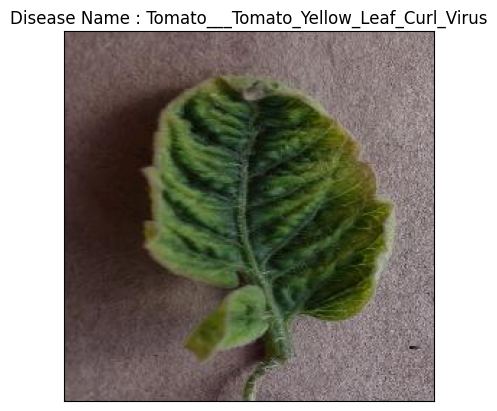

In [31]:
#displaying result
model_prediction=class_name[result_index]
plt.imshow(img)
plt.title(f"Disease Name : {model_prediction}")
plt.xticks([])
plt.yticks([])
plt.show()